In [1]:
import sys, os
from utils import * 


In [2]:
import joblib

DATASET_NAME, X_train, X_test, y_train, y_test = joblib.load("ULB_data.pkl")
y_test = y_test.values.ravel()

MODEL_NAME = "K_Means"
DE_LONG_RESULTS = "ULB_all_results.pkl"
METRICS = "ULB_metrics.pkl"



In [3]:
# ==================================================
# ==================================================
# ==================================================
# ==================================================
# ==================================================
# =================== 3. K-Means ===================
# ==================================================
# ==================================================
# ==================================================
# ==================================================
# ==================================================

In [4]:
# ===================== 3. K-Means =====================
KM_train_scores, KM_test_scores, KM_model = run_kmeans(X_train, X_test)


In [12]:
# ===================== Store metrics =====================
KM_metrics = store_anomaly_metrics(y_true=y_test, scores=-KM_test_scores, dataset_name=DATASET_NAME, model_name=MODEL_NAME)
display(KM_metrics)


,Model,Data,Precision,Precision_CI,Recall,Recall_CI,F1,F1_CI,ROC_AUC,ROC_AUC_CI,PR_AUC,PR_AUC_CI,Confusion_Matrix,Threshold
0,K_Means,creditcard,0.001755,0.000-0.003,0.05102,0.011-0.099,0.003393,0.001-0.007,0.516293,0.454-0.576,0.001882,0.001-0.003,"[[54020, 2844], [93, 5]]",2.437335


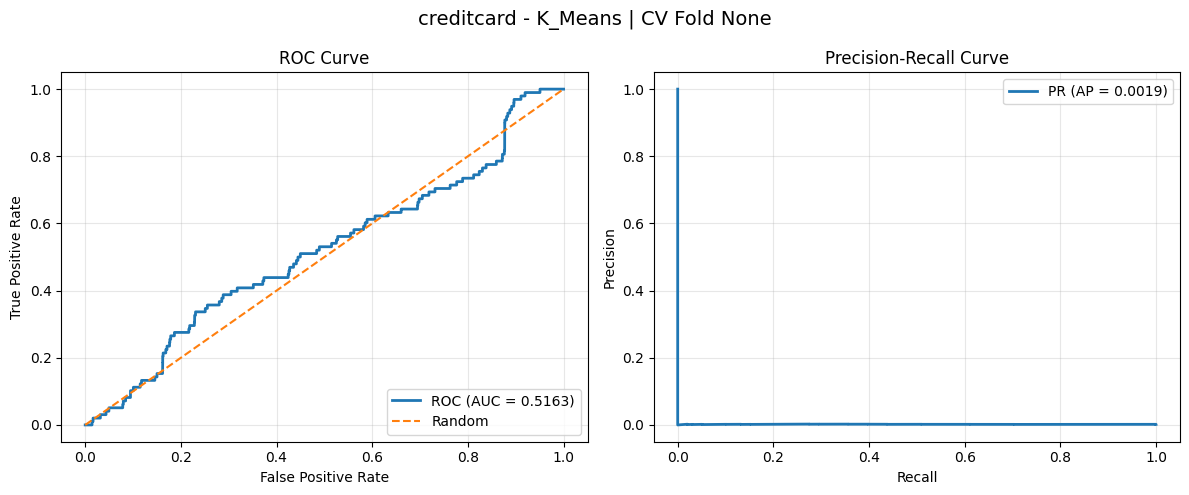

In [13]:
# ===================== Plot results =====================
plot_anomaly_roc_pr(y_true=y_test, scores=-KM_test_scores, dataset_name=DATASET_NAME, model_name=MODEL_NAME)


In [7]:
# ===================== Fit on CV folds =====================
KM_results = fit_cross_validate(X_train, y_train, X_test, y_test, run_kmeans, DATASET_NAME, MODEL_NAME, CV_FOLDS, RANDOM_STATE)


In [8]:
# ===================== Store CV metrics =====================

KM_cv_metrics = pd.concat([r["test_metrics"] for r in KM_results], ignore_index=True)
display(KM_cv_metrics)



,Model,Data,Precision,Precision_CI,Recall,Recall_CI,F1,F1_CI,ROC_AUC,ROC_AUC_CI,PR_AUC,PR_AUC_CI,Confusion_Matrix,Threshold
0,K_Means_Fold1,creditcard,0.000351,0.000-0.001,0.010204,0.000-0.035,0.000679,0.000-0.002,0.448429,0.389-0.509,0.001528,0.001-0.002,"[[54016, 2848], [97, 1]]",-0.893917
1,K_Means_Fold2,creditcard,0.000000,0.000-0.000,0.000000,0.000-0.000,0.000000,0.000-0.000,0.478508,0.424-0.535,0.001605,0.001-0.002,"[[54015, 2849], [98, 0]]",-0.763558
2,K_Means_Fold3,creditcard,0.000702,0.000-0.002,0.020408,0.000-0.052,0.001357,0.000-0.003,0.490911,0.437-0.548,0.001633,0.001-0.002,"[[54017, 2847], [96, 2]]",-0.919235
3,K_Means_Fold4,creditcard,0.001404,0.000-0.003,0.040816,0.010-0.081,0.002715,0.001-0.005,0.538603,0.482-0.596,0.002157,0.002-0.003,"[[54019, 2845], [94, 4]]",-0.891498
4,K_Means_Fold5,creditcard,0.005967,0.003-0.009,0.173469,0.105-0.250,0.011537,0.007-0.017,0.527641,0.472-0.590,0.002281,0.002-0.003,"[[54032, 2832], [81, 17]]",-0.709812


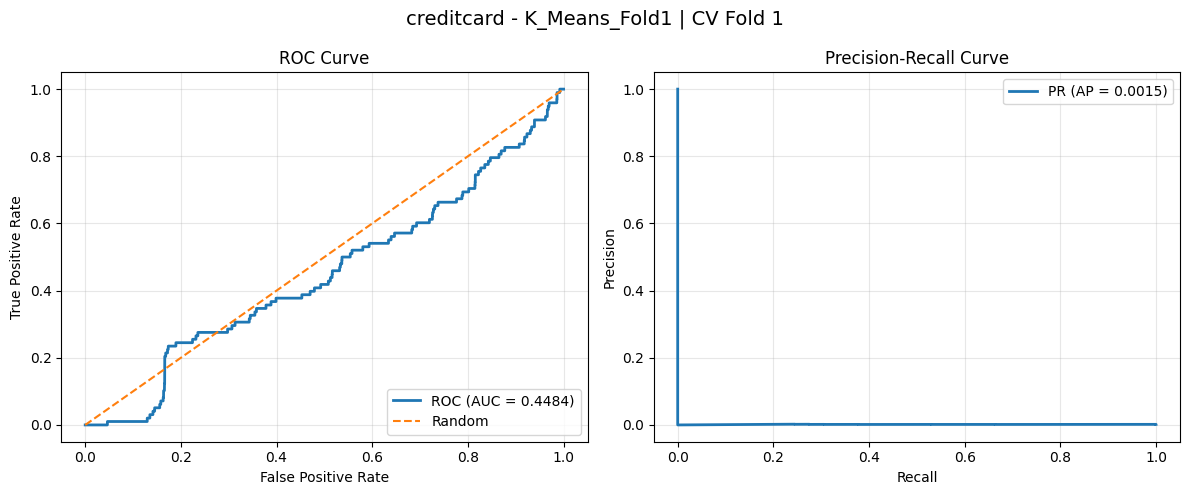

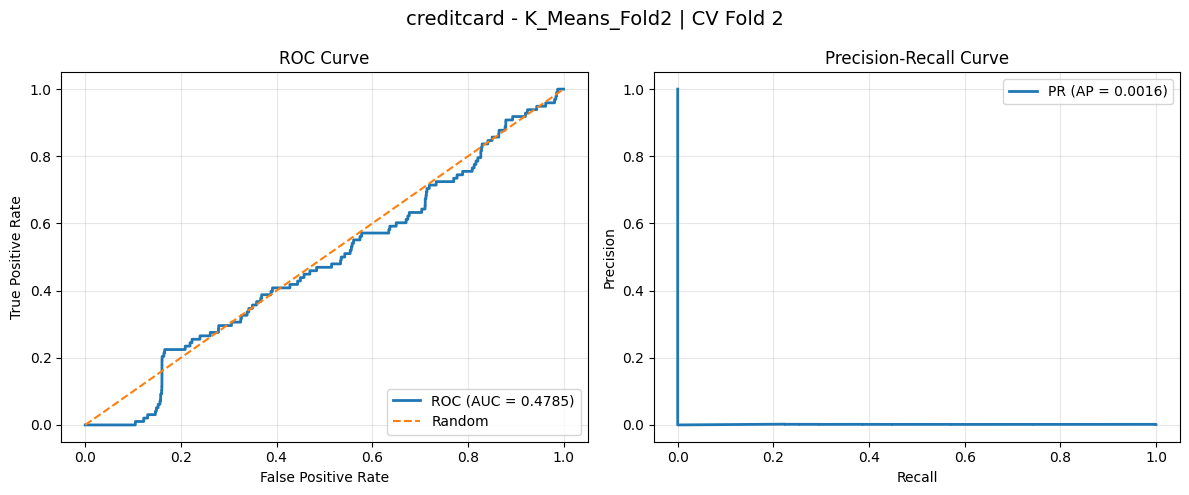

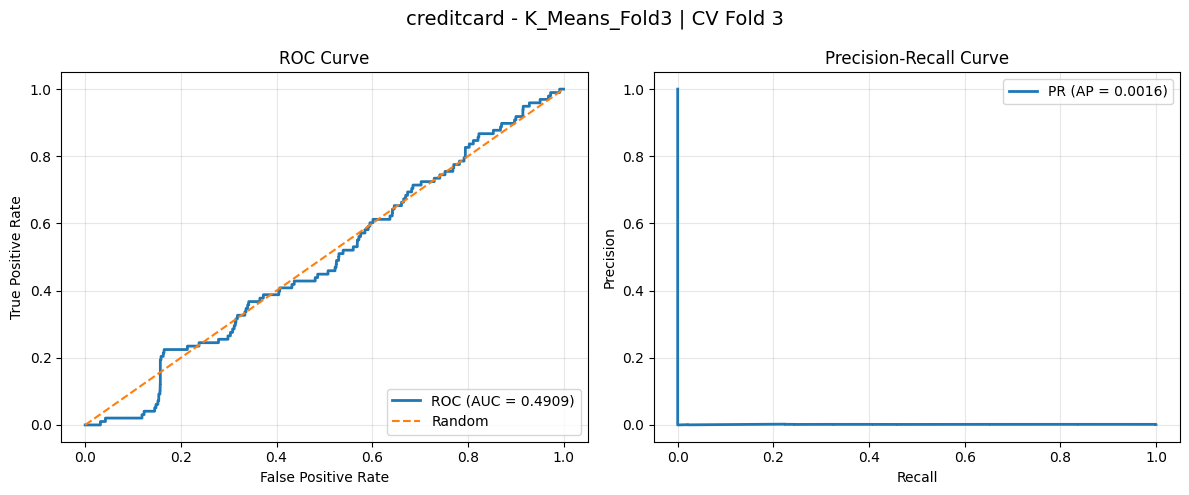

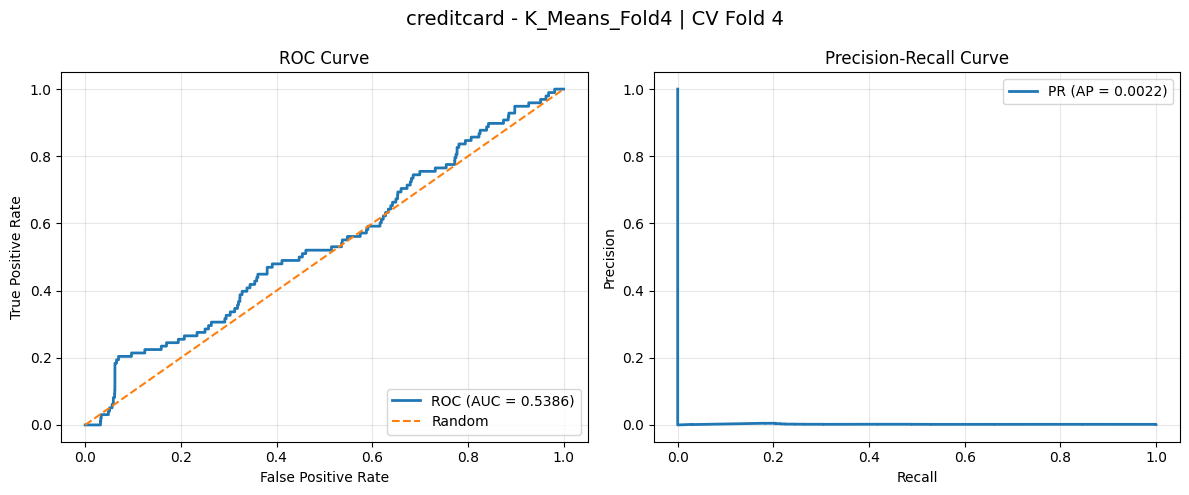

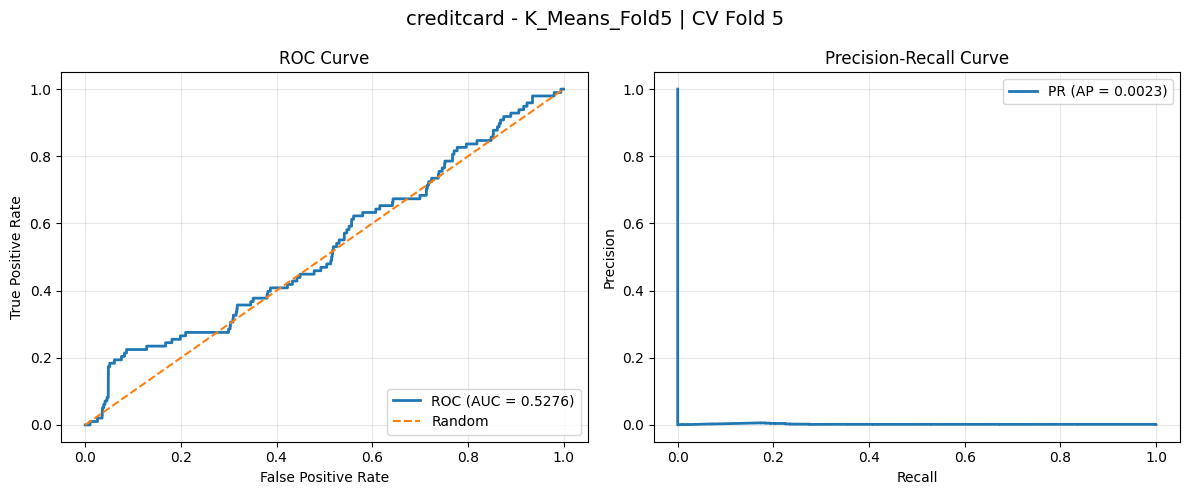

In [9]:
# ===================== Plot CV results =====================

for r in KM_results:
    plot_anomaly_roc_pr(y_test, r["test_scores"], DATASET_NAME, f"{MODEL_NAME}_Fold{r['fold']}", r["fold"])


In [14]:
if os.path.exists(DE_LONG_RESULTS):
    results = joblib.load(DE_LONG_RESULTS)
else:
    results = {}

results[MODEL_NAME] = {
    "test_scores": -KM_test_scores,
    "auc": roc_auc_score(y_test, -KM_test_scores)
}

joblib.dump(results, DE_LONG_RESULTS)

['ULB_all_results.pkl']

In [11]:
if os.path.exists(METRICS):
    results = joblib.load(METRICS)
else:
    results = {}

results[MODEL_NAME] = {
    "metrics": KM_metrics,
    "cv_metrics": KM_cv_metrics
}

joblib.dump(results, METRICS)

['ULB_metrics.pkl']